In [1]:
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import namedtuple, deque
import random
import math
import numpy as np
from itertools import count

from Model.cnnmodel import DQN

import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F

from reward_func import get_reward
from Game_Sim import game

In [2]:
# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

print(device)

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

cuda


In [3]:
"""
    this keeps track of preiovus moves for training
"""

Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [4]:
# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the ``AdamW`` optimizer
BATCH_SIZE = 128 # maybe try higher later
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 10000
TAU = 0.05
LR = 1e-5
TARGET_Q = 5000 # others used 10k

In [5]:
policy_net = DQN(11).to(device) # F(State, Action) -> Reward
target_net = DQN(11).to(device) # Maximize Reward
# policy_net = DQN(1).to(device) # F(State, Action) -> Reward
# target_net = DQN(1).to(device) # Maximize Reward
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

In [6]:
steps_done = 0

from select_action import select_action

In [7]:
episode_durations = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [8]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    
    state_batch = torch.cat(batch.state, dim=0)
    action_batch = torch.cat(batch.action, dim=0).unsqueeze(1)
    reward_batch = torch.cat(batch.reward, dim=0)
    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    # outputs 32x4 tensor
    state_action_values = policy_net(state_batch).gather(0, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros((BATCH_SIZE), device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    # print(state_action_values, expected_state_action_values)

    # Compute MSE loss
    criterion = nn.MSELoss()
    loss = criterion(state_action_values, expected_state_action_values)

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 10) # normal clipping was 100
    optimizer.step()

    return loss.item()

In [9]:
num_episodes = 500 # epochs

model_loss = []

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    g = game.Game(multidimensional=True)
    num_episodes_w_no_movement = 0

    state = g.board.copy()
    # state = torch.tensor(state.flatten(), dtype=torch.float32, device=device).unsqueeze(0) # nn
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0) # cnn
    # state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0) # 3d cnn
    for t in count():
        prev = g.board.copy()

        action, steps_done = select_action(prev, target_net, steps_done, EPS_START, EPS_END, EPS_DECAY)
        
        # print('move is', action,'type is', type(action), end = "\r")
        success, combined_values, combined_indexes = g.move(action)
        action = torch.tensor([action], dtype=torch.int64, device=device)
        observation = g.board.copy()
        
        terminated = g.check_win()
        truncated = g.check_loss()

        reward = get_reward(prev, action, observation, terminated, truncated, success, combined_values, combined_indexes)
        # print('reward is', reward, 'won: ', terminated, 'lost: ', truncated, end="\r")
        
        reward = torch.tensor([reward], dtype=torch.float32, device=device)
        done = terminated or truncated

        if truncated:
            next_state = None
        else:
            # next_state = torch.tensor(observation.flatten(), dtype=torch.float32, device=device).unsqueeze(0)
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0) # cnn
            # next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0) # 3d cnn

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        loss = optimize_model()
        model_loss.append(loss)

        # Soft update of the target network's weights
        if steps_done % TARGET_Q == 0:
            print('updating static network')
            policy_net_state_dict = policy_net.state_dict()
            target_net.load_state_dict(policy_net_state_dict)

        if done:
            # episode_durations.append(t + 1)
            # plot_durations()
            break

    print('done with epoch #{}, max: '.format(i_episode), g.max(), end='\r')

c:\Users\Connie\miniconda3\envs\CS445\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Complete


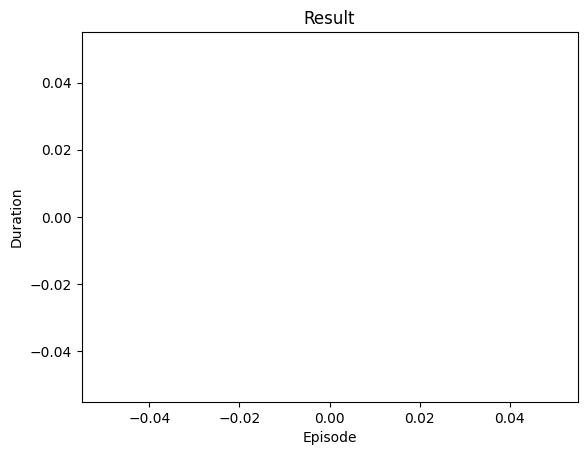

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()

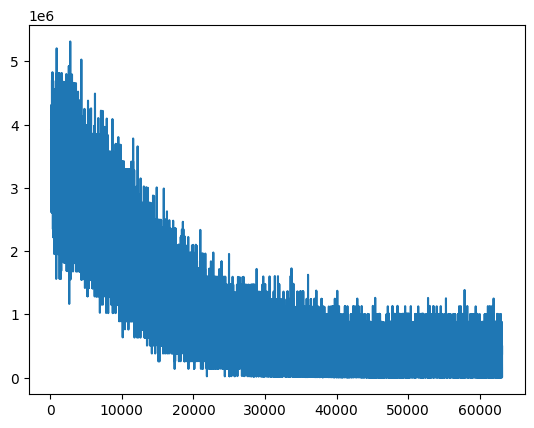

In [ ]:
plt.plot(model_loss)
plt.show()

In [ ]:
target_net_state_dict = target_net.state_dict()
policy_net_state_dict = policy_net.state_dict()

torch.save(target_net_state_dict, 'Model/saved_models/target_net.pt')
torch.save(policy_net_state_dict, 'Model/saved_models/policy_net.pt')